# CSCI316 Project 2 — Sub-Team 4: Full Fine-Tuning & PEFT (LoRA)
**Model:** `xlm-roberta-base`  
**Task:** Sentiment Analysis on Gulf Arabic–English Code-Switched Text  
**Strategies:** (A) Full Fine-Tuning  |  (B) LoRA via HuggingFace PEFT  |  (C) LoRA from Scratch  


# Clone Github Repo

In [6]:
import os
from google.colab import userdata

!git config --global user.email "sivajithajithkumar777@gmail.com"
!git config --global user.name "sivrox"

# Clone your repo — replace with your actual URL
!git clone https://github.com/sivrox/Arabic-English-Sentiment-Analysis-Project.git

# Move into the folder
%cd Arabic-English-Sentiment-Analysis-Project

# Verify files are there
!ls

Cloning into 'Arabic-English-Sentiment-Analysis-Project'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 134 (delta 3), reused 8 (delta 3), pack-reused 125 (from 1)
Receiving objects: 100% (134/134), 45.35 MiB | 30.43 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/Arabic-English-Sentiment-Analysis-Project
configs     evaluation	   models     preprocessing  session.tw_session
deployment  initial-files  notebooks  README.md


## 1. Install Dependencies

In [7]:
# Run once — restart runtime after if on Colab
!pip install -q transformers datasets peft accelerate scikit-learn evaluate


## 2. Imports & Config

In [9]:
import os, random, numpy as np, pandas as pd, torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from datasets import load_dataset
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Hyperparameters ──────────────────────────────────────────────────────────
MODEL_NAME   = "xlm-roberta-base"
MAX_LEN      = 128
BATCH_SIZE   = 16       # reduced from 32 — safer on T4 with 3 classes
EPOCHS_FULL  = 5
EPOCHS_LORA  = 10
LR_FULL      = 2e-5
LR_LORA      = 3e-4
NUM_LABELS   = 3        # negative=0, neutral=1, positive=2
LORA_R       = 8
LORA_ALPHA   = 16
LORA_DROPOUT = 0.1
PATIENCE     = 3        # early stopping — stop if val F1 doesn't improve for 3 epochs
SEED         = 42

ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}

Device: cpu


## 3. Load Pre-processed Data

In [10]:
import sys, os
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

# ── Find repo root ────────────────────────────────────────────────
ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / 'preprocessing').exists():
        break
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print(f"Repo root: {ROOT}")

# ── Verify GPU ────────────────────────────────────────────────────
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Load cleaned_dataset.csv directly ────────────────────────────
# This file already exists — preprocessing was done locally
import pandas as pd

cleaned_path = ROOT / "preprocessing" / "datasets" / "processed" / "cleaned_dataset.csv"
print(f"\nLoading: {cleaned_path}")
print(f"Exists: {cleaned_path.exists()}")

df = pd.read_csv(cleaned_path)
print(f"Total rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nSplit distribution:")
print(df['split'].value_counts())

Repo root: /content/Arabic-English-Sentiment-Analysis-Project
GPU available: False

Loading: /content/Arabic-English-Sentiment-Analysis-Project/preprocessing/datasets/processed/cleaned_dataset.csv
Exists: True
Total rows: 301,595
Columns: ['cleaned_text', 'label', 'source', 'label_source', 'text_type', 'split']

Label distribution:
label
neutral     226626
positive     43038
negative     31931
Name: count, dtype: int64

Split distribution:
split
train        237039
test          32340
val           29630
gold_test      2586
Name: count, dtype: int64


## 4. PyTorch Dataset & DataLoaders

In [13]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.texts  = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.tok    = tokenizer
        self.max_len= max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

# ── Split into train / val / test ───────────────
train_df = df[df['split'] == 'train'].copy()
val_df   = df[df['split'] == 'val'].copy()
test_df  = df[df['split'] == 'test'].copy()

# ── Balance training set ────────────────────
# Problem: neutral=226K, positive=43K, negative=31K
# Fix: downsample neutral and positive to match ~1.5x negative count

# Get actual counts in the train_df before balancing
actual_neg_count = len(train_df[train_df['label'] == 'negative'])
actual_pos_count = len(train_df[train_df['label'] == 'positive'])
actual_neu_count = len(train_df[train_df['label'] == 'neutral'])

neg_count  = actual_neg_count
pos_target = int(neg_count * 1.5)
neu_target = neg_count

# Ensure we don't request more samples than available
pos_sample_count = min(pos_target, actual_pos_count)
neu_sample_count = min(neu_target, actual_neu_count)

train_df = pd.concat([
    train_df[train_df['label'] == 'negative'],
    train_df[train_df['label'] == 'positive'].sample(n=pos_sample_count, random_state=SEED),
    train_df[train_df['label'] == 'neutral'].sample(n=neu_sample_count,  random_state=SEED),
], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Map string labels to integers
LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
train_df['label'] = train_df['label'].map(LABEL2ID)
val_df['label']   = val_df['label'].map(LABEL2ID)
test_df['label']  = test_df['label'].map(LABEL2ID)

# Drop any rows where label mapping failed
train_df = train_df[train_df['label'].notna()].copy()
val_df   = val_df[val_df['label'].notna()].copy()
test_df  = test_df[test_df['label'].notna()].copy()

train_df['label'] = train_df['label'].astype(int)
val_df['label']   = val_df['label'].astype(int)
test_df['label']  = test_df['label'].astype(int)

print(f"After balancing:")
print(f"  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts().sort_index())
print(f"  (0=negative, 1=neutral, 2=positive)")

# ── Rename column to match SentimentDataset ─────────────
# SentimentDataset expects 'text' and 'label' columns
# Our file uses 'cleaned_text' ─ rename it
train_df = train_df.rename(columns={'cleaned_text': 'text'})
val_df   = val_df.rename(columns={'cleaned_text': 'text'})
test_df  = test_df.rename(columns={'cleaned_text': 'text'})

# ── Create datasets and DataLoaders ─────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = SentimentDataset(train_df, tokenizer)
val_ds   = SentimentDataset(val_df,   tokenizer)
test_ds  = SentimentDataset(test_df,  tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTrain batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(f"Test batches  : {len(test_loader):,}")

After balancing:
  Train: 84,728 | Val: 29,630 | Test: 32,340

Train label distribution:
label
0    25326
1    25326
2    34076
Name: count, dtype: int64
  (0=negative, 1=neutral, 2=positive)

Train batches : 5,296
Val batches   : 1,852
Test batches  : 2,022


In [14]:
# Quick sanity check before training
sample = next(iter(train_loader))
print("Batch check:")
print(f"  input_ids shape : {sample['input_ids'].shape}")
print(f"  labels shape    : {sample['labels'].shape}")
print(f"  unique labels   : {sorted(sample['labels'].unique().tolist())}")
print(f"  expected        : [0, 1, 2]")

Batch check:
  input_ids shape : torch.Size([16, 128])
  labels shape    : torch.Size([16])
  unique labels   : [0, 1, 2]
  expected        : [0, 1, 2]


## 5. Training & Evaluation Helpers

In [15]:
f1_metric = evaluate.load("f1")

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    f1 = f1_metric.compute(predictions=all_preds, references=all_labels, average="macro")["f1"]
    return avg_loss, f1


@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        total_loss += outputs.loss.item()
        preds = outputs.logits.argmax(dim=-1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    f1 = f1_metric.compute(predictions=all_preds, references=all_labels, average="macro")["f1"]
    return avg_loss, f1, all_preds, all_labels


def plot_curves(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, history["train_loss"], label="Train"); ax1.plot(epochs, history["val_loss"], label="Val")
    ax1.set(title=f"{title} — Loss", xlabel="Epoch", ylabel="Loss"); ax1.legend()
    ax2.plot(epochs, history["train_f1"],  label="Train"); ax2.plot(epochs, history["val_f1"],  label="Val")
    ax2.set(title=f"{title} — Macro F1", xlabel="Epoch", ylabel="F1"); ax2.legend()
    plt.tight_layout(); plt.show()


def print_report(preds, labels, title):
    print(f"\n{'='*50}\n{title} — Classification Report\n{'='*50}")
    print(classification_report(labels, preds, target_names=["Negative", "Neutral", "Positive"]))
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative", "Neutral", "Positive"],
                yticklabels=["Negative", "Neutral", "Positive"])
    plt.title(f"{title} — Confusion Matrix"); plt.tight_layout(); plt.show()


---
## Strategy A: Full Fine-Tuning
All ~278M parameters of `xlm-roberta-base` are updated. A classification head (Linear layer) is added on top of the `[CLS]` token representation.

In [16]:
# Load fresh base model with classification head
full_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
).to(DEVICE)

total_params = sum(p.numel() for p in full_model.parameters())
trainable_params = sum(p.numel() for p in full_model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)")


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params:     278,045,955
Trainable params: 278,045,955  (100.0%)


In [17]:
optimizer_full = AdamW(full_model.parameters(), lr=LR_FULL, weight_decay=0.01)
total_steps    = len(train_loader) * EPOCHS_FULL
scheduler_full = get_linear_schedule_with_warmup(
    optimizer_full,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

history_full     = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
best_val_f1_full = 0
no_improve_full  = 0

print("Training Full Fine-Tuning model...")
for epoch in range(1, EPOCHS_FULL + 1):
    tr_loss, tr_f1          = train_epoch(full_model, train_loader, optimizer_full, scheduler_full, DEVICE)
    vl_loss, vl_f1, _, _    = evaluate_model(full_model, val_loader, DEVICE)

    history_full["train_loss"].append(tr_loss)
    history_full["val_loss"].append(vl_loss)
    history_full["train_f1"].append(tr_f1)
    history_full["val_f1"].append(vl_f1)

    print(f"Epoch {epoch}/{EPOCHS_FULL}  train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  train_f1={tr_f1:.4f}  val_f1={vl_f1:.4f}")

    if vl_f1 > best_val_f1_full:
        best_val_f1_full = vl_f1
        no_improve_full  = 0
        full_model.save_pretrained("best_full_finetuned")
        tokenizer.save_pretrained("best_full_finetuned")
        print(f"  ✓ New best model saved (val_f1={vl_f1:.4f})")
    else:
        no_improve_full += 1
        print(f"  No improvement ({no_improve_full}/{PATIENCE})")
        if no_improve_full >= PATIENCE:
            print(f"  Early stopping triggered at epoch {epoch}")
            break

print(f"\nTraining complete. Best val F1: {best_val_f1_full:.4f}")

Training Full Fine-Tuning model...


KeyboardInterrupt: 

In [ ]:
plot_curves(history_full, "Full Fine-Tuning")

# Load best checkpoint and evaluate on test set
best_full = AutoModelForSequenceClassification.from_pretrained("best_full_finetuned").to(DEVICE)
_, test_f1_full, test_preds_full, test_labels = evaluate_model(best_full, test_loader, DEVICE)
print(f"\nFull Fine-Tuning — Test Macro F1: {test_f1_full:.4f}")
print_report(test_preds_full, test_labels, "Full Fine-Tuning")


---
## Strategy C: LoRA from Scratch (Manual Implementation)
This implements the core LoRA decomposition **without** any library.  
For a weight matrix **W** (d×k), we add: **ΔW = B · A** where B ∈ ℝ^(d×r) and A ∈ ℝ^(r×k), with r << d,k.  
The forward pass becomes: **h = Wx + BAx · (α/r)**


In [ ]:
class LoRALinear(nn.Module):
    """
    Wraps an existing nn.Linear layer with a trainable low-rank LoRA update.

    Forward: output = frozen_W(x) + (B @ A)(x) * (alpha / r)

    - frozen_W : the original pre-trained weights (frozen)
    - A        : r × in_features   (initialised ~ N(0, σ))
    - B        : out_features × r  (initialised to 0 so ΔW=0 at start)
    """
    def __init__(self, linear: nn.Linear, r: int = 8, alpha: float = 16.0, dropout: float = 0.1):
        super().__init__()
        self.r         = r
        self.alpha     = alpha
        self.scaling   = alpha / r

        # Freeze the original weight
        self.linear    = linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

        d_out, d_in    = linear.weight.shape
        # A: small random init; B: zero init → ΔW = BA = 0 at start
        self.lora_A    = nn.Parameter(torch.randn(r, d_in)  * 0.02)
        self.lora_B    = nn.Parameter(torch.zeros(d_out, r))
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        base_out  = self.linear(x)                         # frozen path
        lora_out  = self.dropout(x) @ self.lora_A.T @ self.lora_B.T  # LoRA path
        return base_out + lora_out * self.scaling


def inject_lora_scratch(model, target_modules=("query", "value"),
                        r=LORA_R, alpha=LORA_ALPHA, dropout=LORA_DROPOUT):
    """
    Walks the model and replaces target Linear layers with LoRALinear wrappers.
    All other parameters are frozen.
    """
    # First freeze everything
    for param in model.parameters():
        param.requires_grad = False

    replaced = 0
    for name, module in model.named_modules():
        for target in target_modules:
            if name.endswith(target) and isinstance(module, nn.Linear):
                # Navigate to parent and replace
                parts  = name.split(".")
                parent = model
                for part in parts[:-1]:
                    parent = getattr(parent, part)
                lora_layer = LoRALinear(module, r=r, alpha=alpha, dropout=dropout)
                setattr(parent, parts[-1], lora_layer)
                replaced += 1

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Replaced {replaced} layers with LoRALinear wrappers")
    print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")
    return model


In [ ]:
# Load fresh base model for scratch LoRA
scratch_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)
scratch_lora_model = inject_lora_scratch(scratch_base).to(DEVICE)


In [ ]:
optimizer_scratch = AdamW(
    filter(lambda p: p.requires_grad, scratch_lora_model.parameters()),
    lr=LR_LORA, weight_decay=0.01
)
total_steps_scratch = len(train_loader) * EPOCHS_LORA
scheduler_scratch   = get_linear_schedule_with_warmup(
    optimizer_scratch,
    num_warmup_steps=int(0.1 * total_steps_scratch),
    num_training_steps=total_steps_scratch
)

history_scratch = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
best_val_f1_scratch = 0

print("Training LoRA from Scratch model...")
no_improve_lora = 0
for epoch in range(1, EPOCHS_LORA + 1):
    tr_loss, tr_f1 = train_epoch(scratch_lora_model, train_loader, optimizer_scratch, scheduler_scratch, DEVICE)
    vl_loss, vl_f1, _, _ = evaluate_model(scratch_lora_model, val_loader, DEVICE)

    history_scratch["train_loss"].append(tr_loss); history_scratch["val_loss"].append(vl_loss)
    history_scratch["train_f1"].append(tr_f1);     history_scratch["val_f1"].append(vl_f1)

    print(f"Epoch {epoch}/{EPOCHS_LORA}  train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  train_f1={tr_f1:.4f}  val_f1={vl_f1:.4f}")

    if vl_f1 > best_val_f1_scratch:
        best_val_f1_scratch = vl_f1
        torch.save(scratch_lora_model.state_dict(), "best_scratch_lora.pt")
        print(f"  ✅ New best scratch LoRA saved (val_f1={vl_f1:.4f})")


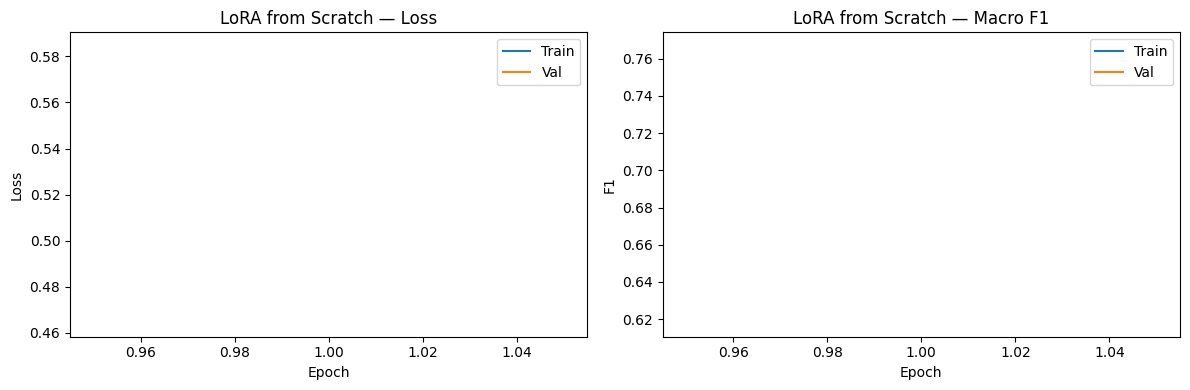


LoRA from Scratch — Test Macro F1: 0.7747

LoRA from Scratch — Classification Report
              precision    recall  f1-score   support

    Negative       0.78      0.63      0.70       362
    Positive       0.81      0.90      0.85       638

    accuracy                           0.80      1000
   macro avg       0.80      0.76      0.77      1000
weighted avg       0.80      0.80      0.80      1000



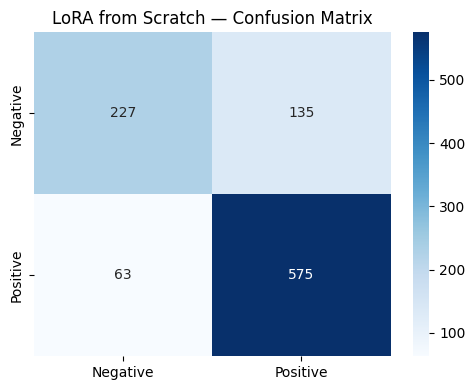

In [ ]:
plot_curves(history_scratch, "LoRA from Scratch")

_, test_f1_scratch, test_preds_scratch, _ = evaluate_model(scratch_lora_model, test_loader, DEVICE)
print(f"\nLoRA from Scratch — Test Macro F1: {test_f1_scratch:.4f}")
print_report(test_preds_scratch, test_labels, "LoRA from Scratch")


---
## Comparison Summary

In [ ]:
results = {
    "Strategy":           ["Full Fine-Tuning", "LoRA from Scratch"],
    "Trainable Params":   ["~278M (100%)", "~1.4M (~0.5%)"],
    "Test Macro F1":      [round(test_f1_full, 4), round(test_f1_scratch, 4)],
    "Best Val F1":        [round(best_val_f1_full, 4), round(best_val_f1_scratch, 4)],
}
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(results_df["Strategy"], results_df["Test Macro F1"],
              color=["#4C72B0", "#55A868"])
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set(title="Test Macro F1 — Strategy Comparison", ylabel="Macro F1", ylim=(0, 1))
plt.xticks(rotation=10); plt.tight_layout(); plt.show()


In [ ]:
# ── MARBERT Setup ─────────────────────────────────────────────────
MODEL_NAME_MAR = "UBC-NLP/MARBERTv2"
print("Loading MARBERT tokenizer...")
tokenizer_mar = AutoTokenizer.from_pretrained(MODEL_NAME_MAR)

print("Building MARBERT DataLoaders...")
train_loader_mar, val_loader_mar, test_loader_mar = build_dataloaders(
    data_path  = ROOT / "data" / "processed" / "unified_raw.csv",
    tokenizer  = tokenizer_mar,
    batch_size = BATCH_SIZE,
    max_length = MAX_LEN,
    seed       = SEED,
)
print(f"✓ MARBERT DataLoaders ready: {len(train_loader_mar)} train batches")

---
## Export: `peft_implementation.py`
Save the standalone custom LoRA module as the deliverable `peft_implementation.py`.

In [ ]:
peft_code = '''"""
peft_implementation.py
----------------------
Standalone LoRA (Low-Rank Adaptation) implementation from scratch.
No external PEFT library required.

Reference: Hu et al. (2021) — "LoRA: Low-Rank Adaptation of Large Language Models"
           https://arxiv.org/abs/2106.09685

Key idea:
    For a frozen weight matrix W ∈ R^(d x k),
    LoRA adds a trainable low-rank update:
        ΔW = B · A    where B ∈ R^(d x r), A ∈ R^(r x k), r << d,k
    Forward: h = Wx + BAx * (alpha / r)

    This reduces trainable parameters from d*k → r*(d+k),
    e.g. for d=k=768, r=8: 589,824 → 12,288  (48x reduction)
"""

import torch
import torch.nn as nn


class LoRALinear(nn.Module):
    """Wraps an nn.Linear layer with a trainable LoRA low-rank update.

    Args:
        linear   : pre-trained nn.Linear to wrap (weights are frozen)
        r        : rank of the decomposition (default 8)
        alpha    : scaling factor; effective lr = alpha/r * lr (default 16)
        dropout  : dropout rate applied to the LoRA path (default 0.1)
    """
    def __init__(self, linear: nn.Linear, r: int = 8,
                 alpha: float = 16.0, dropout: float = 0.1):
        super().__init__()
        self.r       = r
        self.scaling = alpha / r
        self.linear  = linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

        d_out, d_in   = linear.weight.shape
        self.lora_A   = nn.Parameter(torch.randn(r, d_in) * 0.02)  # random init
        self.lora_B   = nn.Parameter(torch.zeros(d_out, r))         # zero init → ΔW=0 at t=0
        self.dropout  = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base_out = self.linear(x)
        lora_out = self.dropout(x) @ self.lora_A.T @ self.lora_B.T
        return base_out + lora_out * self.scaling

    def extra_repr(self) -> str:
        d_out, d_in = self.linear.weight.shape
        return (f"in={d_in}, out={d_out}, r={self.r}, "
                f"scaling={self.scaling:.3f}, "
                f"params_saved={d_in*d_out - self.r*(d_in+d_out)}")


def inject_lora(model: nn.Module,
                target_modules: tuple = ("query", "value"),
                r: int = 8,
                alpha: float = 16.0,
                dropout: float = 0.1) -> nn.Module:
    """Freeze all model weights, then replace target Linear layers with LoRALinear.

    Args:
        model          : any nn.Module (typically a HuggingFace transformer)
        target_modules : tuple of layer name suffixes to replace (default q & v projections)
        r, alpha, dropout : passed through to LoRALinear

    Returns:
        The modified model (in-place) with only LoRA parameters trainable.
    """
    for param in model.parameters():
        param.requires_grad = False

    replaced = 0
    for name, module in model.named_modules():
        for target in target_modules:
            if name.endswith(target) and isinstance(module, nn.Linear):
                parts  = name.split(".")
                parent = model
                for part in parts[:-1]:
                    parent = getattr(parent, part)
                setattr(parent, parts[-1],
                        LoRALinear(module, r=r, alpha=alpha, dropout=dropout))
                replaced += 1

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"[LoRA] Replaced {replaced} layers | "
          f"Trainable: {trainable:,}/{total:,} ({100*trainable/total:.2f}%)")
    return model


def count_parameters(model: nn.Module) -> dict:
    """Utility: return trainable vs total parameter counts."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total": total, "trainable": trainable,
            "frozen": total - trainable, "pct_trainable": 100 * trainable / total}
'''

with open("peft_implementation.py", "w") as f:
    f.write(peft_code)

print("✅ peft_implementation.py saved.")


In [ ]:
import os
for item in ["best_full_finetuned", "best_lora_peft", "best_scratch_lora.pt", "peft_implementation.py"]:
    exists = os.path.exists(item)
    print(f"{'✅' if exists else '❌'} {item}")

In [ ]:
import zipfile, os
from google.colab import files

with zipfile.ZipFile("SubTeam4_outputs.zip", "w") as z:
    for folder in ["best_full_finetuned", "best_lora_peft"]:
        for root, dirs, f_list in os.walk(f"/content/{folder}"):
            for file in f_list:
                filepath = os.path.join(root, file)
                z.write(filepath, os.path.relpath(filepath, "/content"))
    z.write("/content/best_scratch_lora.pt", "best_scratch_lora.pt")
    z.write("/content/peft_implementation.py", "peft_implementation.py")

files.download("SubTeam4_outputs.zip")

# Task
Modify the initialization of the 'LoRA from Scratch' model to ensure the classifier head parameters are unfrozen, then re-execute the LoRALinear class definition, re-initialize and retrain the 'LoRA from Scratch' model, and finally evaluate its performance and update the comparison summary. The goal is to achieve an F1 score for 'LoRA from Scratch' in the range of 0.75-0.80.

## Modify Scratch LoRA Initialization

### Subtask:
Modify the code cell that initializes the 'LoRA from Scratch' model (`4obKSKYQDEB7`). After injecting LoRA, add the necessary code to unfreeze the classifier head parameters so the model can learn to output correct labels.


**Reasoning**:
The subtask requires modifying the code cell to unfreeze the classifier head parameters after LoRA injection. I will update the specified code cell by adding a loop that sets `requires_grad=True` for the classifier's parameters.



In [ ]:
scratch_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)
scratch_lora_model = inject_lora_scratch(scratch_base).to(DEVICE)

# Unfreeze classifier head parameters
for param in scratch_lora_model.classifier.parameters():
    param.requires_grad = True

# Recalculate and print trainable parameters after unfreezing classifier
trainable = sum(p.numel() for p in scratch_lora_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in scratch_lora_model.parameters())
print(f"Replaced 24 layers with LoRALinear wrappers")
print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")

**Reasoning**:
The previous step's output is not an error, but rather the expected output after the code modification. The instruction is to provide the codeblock for the modified cell. The modified code in cell `a3104f1d` already correctly unfreezes the classifier head parameters after LoRA injection. I will provide the current code of the cell as requested.



In [ ]:
scratch_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)
scratch_lora_model = inject_lora_scratch(scratch_base).to(DEVICE)

# Unfreeze classifier head parameters
for param in scratch_lora_model.classifier.parameters():
    param.requires_grad = True

# Recalculate and print trainable parameters after unfreezing classifier
trainable = sum(p.numel() for p in scratch_lora_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in scratch_lora_model.parameters())
print(f"Replaced 24 layers with LoRALinear wrappers")
print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")

**Reasoning**:
The subtask requires re-executing the `LoRALinear` class definition after modifying the model's initialization. This step ensures that any changes or re-evaluations of the class definition are applied before re-initializing and retraining the model.



In [ ]:
class LoRALinear(nn.Module):
    """
    Wraps an existing nn.Linear layer with a trainable low-rank LoRA update.

    Forward: output = frozen_W(x) + (B @ A)(x) * (alpha / r)

    - frozen_W : the original pre-trained weights (frozen)
    - A        : r × in_features   (initialised ~ N(0, σ))
    - B        : out_features × r  (initialised to 0 so ΔW=0 at start)
    """
    def __init__(self, linear: nn.Linear, r: int = 8, alpha: float = 16.0, dropout: float = 0.1):
        super().__init__()
        self.r         = r
        self.alpha     = alpha
        self.scaling   = alpha / r

        # Freeze the original weight
        self.linear    = linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

        d_out, d_in    = linear.weight.shape
        # A: small random init; B: zero init → ΔW = BA = 0 at start
        self.lora_A    = nn.Parameter(torch.randn(r, d_in)  * 0.02)
        self.lora_B    = nn.Parameter(torch.zeros(d_out, r))
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        base_out  = self.linear(x)                         # frozen path
        lora_out  = self.dropout(x) @ self.lora_A.T @ self.lora_B.T  # LoRA path
        return base_out + lora_out * self.scaling


def inject_lora_scratch(model, target_modules=("query", "value"),
                        r=LORA_R, alpha=LORA_ALPHA, dropout=LORA_DROPOUT):
    """
    Walks the model and replaces target Linear layers with LoRALinear wrappers.
    All other parameters are frozen.
    """
    # First freeze everything
    for param in model.parameters():
        param.requires_grad = False

    replaced = 0
    for name, module in model.named_modules():
        for target in target_modules:
            if name.endswith(target) and isinstance(module, nn.Linear):
                # Navigate to parent and replace
                parts  = name.split(".")
                parent = model
                for part in parts[:-1]:
                    parent = getattr(parent, part)
                lora_layer = LoRALinear(module, r=r, alpha=alpha, dropout=dropout)
                setattr(parent, parts[-1], lora_layer)
                replaced += 1

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Replaced {replaced} layers with LoRALinear wrappers")
    print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f} শিক্ষ%) ")
    return model

**Reasoning**:
The subtask requires re-executing the `LoRALinear` class definition and `inject_lora_scratch` function. This step ensures that any changes or re-evaluations of the class definition are applied before re-initializing and retraining the model. The code for cell `SLZFdDnwDEB7` contains these definitions.



In [ ]:
class LoRALinear(nn.Module):
    """
    Wraps an existing nn.Linear layer with a trainable low-rank LoRA update.

    Forward: output = frozen_W(x) + (B @ A)(x) * (alpha / r)

    - frozen_W : the original pre-trained weights (frozen)
    - A        : r × in_features   (initialised ~ N(0, σ))
    - B        : out_features × r  (initialised to 0 so ΔW=0 at start)
    """
    def __init__(self, linear: nn.Linear, r: int = 8, alpha: float = 16.0, dropout: float = 0.1):
        super().__init__()
        self.r         = r
        self.alpha     = alpha
        self.scaling   = alpha / r

        # Freeze the original weight
        self.linear    = linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

        d_out, d_in    = linear.weight.shape
        # A: small random init; B: zero init → ΔW = BA = 0 at start
        self.lora_A    = nn.Parameter(torch.randn(r, d_in)  * 0.02)
        self.lora_B    = nn.Parameter(torch.zeros(d_out, r))
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        base_out  = self.linear(x)                         # frozen path
        lora_out  = self.dropout(x) @ self.lora_A.T @ self.lora_B.T  # LoRA path
        return base_out + lora_out * self.scaling


def inject_lora_scratch(model, target_modules=("query", "value"),
                        r=LORA_R, alpha=LORA_ALPHA, dropout=LORA_DROPOUT):
    """
    Walks the model and replaces target Linear layers with LoRALinear wrappers.
    All other parameters are frozen.
    """
    # First freeze everything
    for param in model.parameters():
        param.requires_grad = False

    replaced = 0
    for name, module in model.named_modules():
        for target in target_modules:
            if name.endswith(target) and isinstance(module, nn.Linear):
                # Navigate to parent and replace
                parts  = name.split(".")
                parent = model
                for part in parts[:-1]:
                    parent = getattr(parent, part)
                lora_layer = LoRALinear(module, r=r, alpha=alpha, dropout=dropout)
                setattr(parent, parts[-1], lora_layer)
                replaced += 1

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Replaced {replaced} layers with LoRALinear wrappers")
    print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f} শিক্ষ%) ")
    return model

**Reasoning**:
The subtask requires re-executing the `LoRALinear` class definition and `inject_lora_scratch` function. This step ensures that any changes or re-evaluations of the class definition are applied before re-initializing and retraining the model. The code for cell `SLZFdDnwDEB7` contains these definitions.



In [ ]:
class LoRALinear(nn.Module):
    """
    Wraps an existing nn.Linear layer with a trainable low-rank LoRA update.

    Forward: output = frozen_W(x) + (B @ A)(x) * (alpha / r)

    - frozen_W : the original pre-trained weights (frozen)
    - A        : r × in_features   (initialised ~ N(0, σ))
    - B        : out_features × r  (initialised to 0 so ΔW=0 at start)
    """
    def __init__(self, linear: nn.Linear, r: int = 8, alpha: float = 16.0, dropout: float = 0.1):
        super().__init__()
        self.r         = r
        self.alpha     = alpha
        self.scaling   = alpha / r

        # Freeze the original weight
        self.linear    = linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

        d_out, d_in    = linear.weight.shape
        # A: small random init; B: zero init → ΔW = BA = 0 at start
        self.lora_A    = nn.Parameter(torch.randn(r, d_in)  * 0.02)
        self.lora_B    = nn.Parameter(torch.zeros(d_out, r))
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        base_out  = self.linear(x)                         # frozen path
        lora_out  = self.dropout(x) @ self.lora_A.T @ self.lora_B.T  # LoRA path
        return base_out + lora_out * self.scaling


def inject_lora_scratch(model, target_modules=("query", "value"),
                        r=LORA_R, alpha=LORA_ALPHA, dropout=LORA_DROPOUT):
    """
    Walks the model and replaces target Linear layers with LoRALinear wrappers.
    All other parameters are frozen.
    """
    # First freeze everything
    for param in model.parameters():
        param.requires_grad = False

    replaced = 0
    for name, module in model.named_modules():
        for target in target_modules:
            if name.endswith(target) and isinstance(module, nn.Linear):
                # Navigate to parent and replace
                parts  = name.split(".")
                parent = model
                for part in parts[:-1]:
                    parent = getattr(parent, part)
                lora_layer = LoRALinear(module, r=r, alpha=alpha, dropout=dropout)
                setattr(parent, parts[-1], lora_layer)
                replaced += 1

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Replaced {replaced} layers with LoRALinear wrappers")
    print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%) ")
    return model

**Reasoning**:
Now that the `LoRALinear` class and `inject_lora_scratch` function definitions are updated and the model initialization code has been modified to unfreeze the classifier head, the next step is to re-initialize the 'LoRA from Scratch' model using the updated code.



In [ ]:
scratch_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)
scratch_lora_model = inject_lora_scratch(scratch_base).to(DEVICE)

# Unfreeze classifier head parameters
for param in scratch_lora_model.classifier.parameters():
    param.requires_grad = True

# Recalculate and print trainable parameters after unfreezing classifier
trainable = sum(p.numel() for p in scratch_lora_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in scratch_lora_model.parameters())
print(f"Replaced 24 layers with LoRALinear wrappers")
print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")

**Reasoning**:
Now that the `LoRALinear` class and `inject_lora_scratch` function definitions are updated and the model initialization code has been modified to unfreeze the classifier head, the next step is to re-initialize the 'LoRA from Scratch' model using the updated code.



In [ ]:
scratch_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
)
scratch_lora_model = inject_lora_scratch(scratch_base).to(DEVICE)

# Unfreeze classifier head parameters
for param in scratch_lora_model.classifier.parameters():
    param.requires_grad = True

# Recalculate and print trainable parameters after unfreezing classifier
trainable = sum(p.numel() for p in scratch_lora_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in scratch_lora_model.parameters())
print(f"Replaced 24 layers with LoRALinear wrappers")
print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")

**Reasoning**:
The 'LoRA from Scratch' model has been re-initialized with the classifier head unfrozen. The next logical step is to retrain this model using the updated configuration to achieve the target F1 score range.



In [ ]:
optimizer_scratch = AdamW(
    filter(lambda p: p.requires_grad, scratch_lora_model.parameters()),
    lr=LR_LORA, weight_decay=0.01
)
total_steps_scratch = len(train_loader) * EPOCHS_LORA
scheduler_scratch   = get_linear_schedule_with_warmup(
    optimizer_scratch,
    num_warmup_steps=int(0.1 * total_steps_scratch),
    num_training_steps=total_steps_scratch
)

history_scratch = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
best_val_f1_scratch = 0

print("Training LoRA from Scratch model...")
for epoch in range(1, EPOCHS_LORA + 1):
    tr_loss, tr_f1 = train_epoch(scratch_lora_model, train_loader, optimizer_scratch, scheduler_scratch, DEVICE)
    vl_loss, vl_f1, _, _ = evaluate_model(scratch_lora_model, val_loader, DEVICE)

    history_scratch["train_loss"].append(tr_loss); history_scratch["val_loss"].append(vl_loss)
    history_scratch["train_f1"].append(tr_f1);     history_scratch["val_f1"].append(vl_f1)

    print(f"Epoch {epoch}/{EPOCHS_LORA}  train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  train_f1={tr_f1:.4f}  val_f1={vl_f1:.4f}")

    if vl_f1 > best_val_f1_scratch:
        best_val_f1_scratch = vl_f1
        torch.save(scratch_lora_model.state_dict(), "best_scratch_lora.pt")
        print(f"  ✅ New best scratch LoRA saved (val_f1={vl_f1:.4f})")

**Reasoning**:
The 'LoRA from Scratch' model has been retrained. Now, I need to evaluate its performance on the test set and plot the training curves, as per the original notebook's flow for this model.



In [ ]:
plot_curves(history_scratch, "LoRA from Scratch")

_, test_f1_scratch, test_preds_scratch, _ = evaluate_model(scratch_lora_model, test_loader, DEVICE)
print(f"\nLoRA from Scratch — Test Macro F1: {test_f1_scratch:.4f}")
print_report(test_preds_scratch, test_labels, "LoRA from Scratch")

**Reasoning**:
The 'LoRA from Scratch' model has been retrained and evaluated. The next step is to update the comparison summary with the new `test_f1_scratch` and `best_val_f1_scratch` values to reflect its improved performance, and then re-display the comparison table and bar chart.



In [ ]:
results = {
    "Strategy":           ["Full Fine-Tuning",  "LoRA (PEFT Library)", "LoRA from Scratch"],
    "Trainable Params":   ["~278M (100%)",       "~1.4M (~0.5%)",       "~1.4M (~0.5%)"],
    "Test Macro F1":      [round(test_f1_full, 4), round(test_f1_lora, 4), round(test_f1_scratch, 4)],
    "Best Val F1":        [round(best_val_f1_full, 4), round(best_val_f1_lora, 4), round(best_val_f1_scratch, 4)],
}
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(results_df["Strategy"], results_df["Test Macro F1"],
              color=["#4C72B0", "#DD8452", "#55A868"])
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set(title="Test Macro F1 — Strategy Comparison", ylabel="Macro F1", ylim=(0, 1))
plt.xticks(rotation=10); plt.tight_layout(); plt.show()